# Supervised Learning


## Setup
Cell pertama akan meng-install package langsung ke kernel aktif, jadi kamu tidak perlu file `requirements.txt` terpisah lagi.


In [85]:
import sys, subprocess
packages = ['numpy','pandas','matplotlib','scikit-learn','scipy','mglearn','ipykernel']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *packages])
print('Semua package utama sudah dipastikan terpasang pada kernel ini.')


Semua package utama sudah dipastikan terpasang pada kernel ini.


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mglearn

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_iris, make_blobs, make_circles
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler


## 1. Classification dan Regression
Supervised learning dibagi menjadi classification untuk memprediksi kelas dan regression untuk memprediksi nilai kontinu.


In [87]:
print('Classification: memprediksi label kelas')
print('Regression    : memprediksi nilai kontinu')


Classification: memprediksi label kelas
Regression    : memprediksi nilai kontinu


## 2. Generalization, Overfitting, Underfitting
Model yang baik harus bisa generalisasi ke data baru. Overfitting berarti model terlalu hafal data train, sedangkan underfitting berarti model terlalu sederhana.


In [88]:
print('Overfitting  : train tinggi, test rendah')
print('Underfitting : train dan test sama-sama rendah')
print('Generalisasi : train dan test seimbang serta baik')


Overfitting  : train tinggi, test rendah
Underfitting : train dan test sama-sama rendah
Generalisasi : train dan test seimbang serta baik


## 3. Dataset contoh
Bagian ini menyiapkan dataset sintetis dan dataset real-world yang dipakai pada beberapa model.


In [89]:
X_forge, y_forge = mglearn.datasets.make_forge()
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)
cancer = load_breast_cancer()
X_boston, y_boston = mglearn.datasets.load_extended_boston()

print('Forge shape :', X_forge.shape)
print('Wave shape  :', X_wave.shape)
print('Cancer shape:', cancer.data.shape)
print('Boston shape:', X_boston.shape)


Forge shape : (26, 2)
Wave shape  : (40, 1)
Cancer shape: (569, 30)
Boston shape: (506, 104)


## 4. Visualisasi dataset sederhana
Forge dipakai untuk classification sederhana dan wave dipakai untuk regression sederhana.


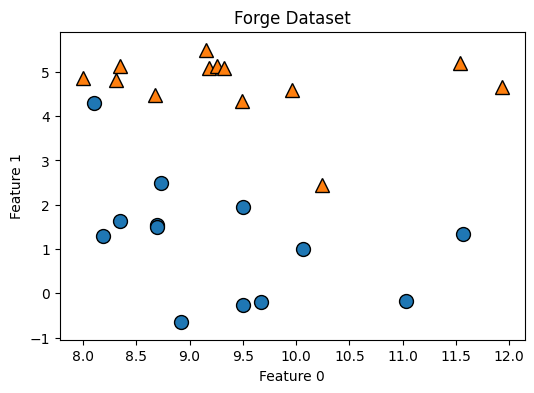

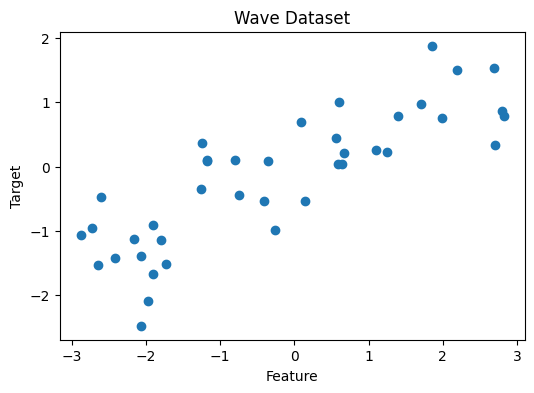

In [90]:
plt.figure(figsize=(6, 4))
mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Forge Dataset')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(X_wave, y_wave, 'o')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Wave Dataset')
plt.show()


## 5. k-NN Classification
K-Nearest Neighbors mengklasifikasikan data baru berdasarkan tetangga terdekatnya.


In [91]:
X_train, X_test, y_train, y_test = train_test_split(X_forge, y_forge, random_state=0)
knn_clf = KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train, y_train)
print('Prediksi test:', knn_clf.predict(X_test))
print('Akurasi test :', round(knn_clf.score(X_test, y_test), 2))


Prediksi test: [1 0 1 0 1 0 0]
Akurasi test : 0.86


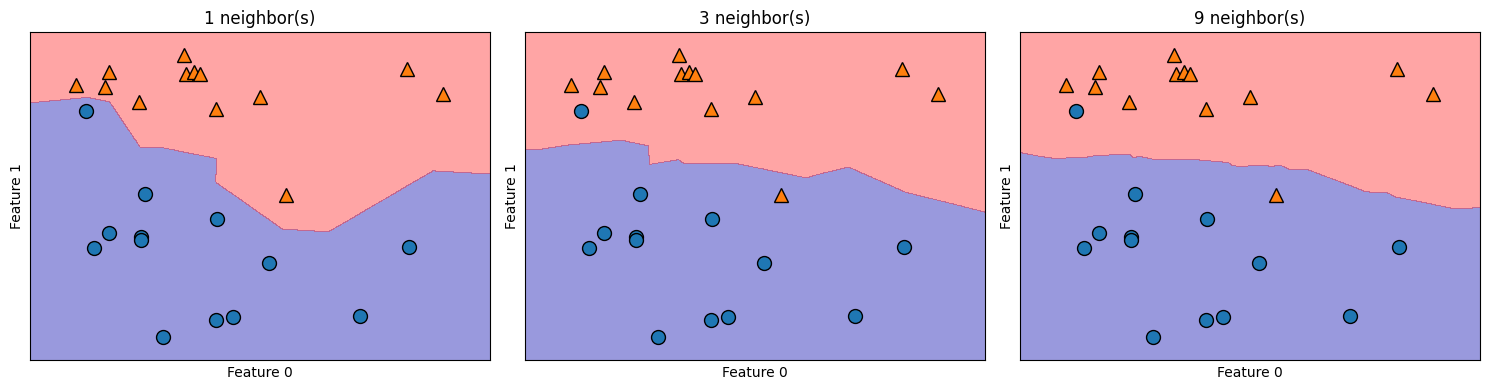

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n_neighbors, ax in zip([1, 3, 9], axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X_forge, y_forge)
    mglearn.plots.plot_2d_separator(clf, X_forge, fill=True, eps=0.5, ax=ax, alpha=0.4)
    mglearn.discrete_scatter(X_forge[:, 0], X_forge[:, 1], y_forge, ax=ax)
    ax.set_title(f'{n_neighbors} neighbor(s)')
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')
plt.tight_layout()
plt.show()


## 6. k-NN pada breast cancer
Akurasi train dan test pada beberapa nilai `n_neighbors` membantu melihat kapan model overfit atau underfit.


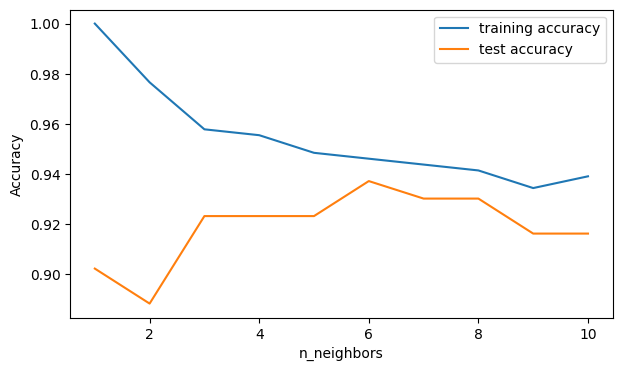

In [93]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)
training_accuracy, test_accuracy = [], []
for n_neighbors in range(1, 11):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), training_accuracy, label='training accuracy')
plt.plot(range(1, 11), test_accuracy, label='test accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 7. k-NN Regression
Untuk regresi, k-NN memprediksi nilai target dari rata-rata tetangga terdekat.


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X_wave, y_wave, random_state=0)
knn_reg = KNeighborsRegressor(n_neighbors=3).fit(X_train, y_train)
print('Prediksi test:', np.round(knn_reg.predict(X_test), 3))
print('R^2 test    :', round(knn_reg.score(X_test, y_test), 2))


Prediksi test: [-0.054  0.357  1.137 -1.894 -1.139 -1.631  0.357  0.912 -0.447 -1.139]
R^2 test    : 0.83


## 8. Linear Regression
Linear Regression membuat prediksi sebagai kombinasi linear dari fitur dan sering dipakai sebagai baseline regresi.


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_wave, y_wave, random_state=42)
lr_wave = LinearRegression().fit(X_train, y_train)
print('coef_     :', np.round(lr_wave.coef_, 3))
print('intercept_:', round(lr_wave.intercept_, 3))
print('Train R^2 :', round(lr_wave.score(X_train, y_train), 2))
print('Test R^2  :', round(lr_wave.score(X_test, y_test), 2))


coef_     : [0.48]
intercept_: -0.098
Train R^2 : 0.65
Test R^2  : 0.77


## 9. Linear Regression pada extended Boston
Saat fitur bertambah banyak, linear regression bisa overfit.


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X_boston, y_boston, random_state=0)
lr = LinearRegression().fit(X_train, y_train)
print('Train R^2:', round(lr.score(X_train, y_train), 2))
print('Test R^2 :', round(lr.score(X_test, y_test), 2))


Train R^2: 0.95
Test R^2 : 0.61


## 10. Ridge Regression
Ridge memakai regularisasi L2 untuk menekan koefisien agar tidak terlalu besar.


In [97]:
ridge = Ridge().fit(X_train, y_train)
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print('alpha=1   | Train:', round(ridge.score(X_train, y_train), 2), '| Test:', round(ridge.score(X_test, y_test), 2))
print('alpha=10  | Train:', round(ridge10.score(X_train, y_train), 2), '| Test:', round(ridge10.score(X_test, y_test), 2))
print('alpha=0.1 | Train:', round(ridge01.score(X_train, y_train), 2), '| Test:', round(ridge01.score(X_test, y_test), 2))


alpha=1   | Train: 0.89 | Test: 0.75
alpha=10  | Train: 0.79 | Test: 0.64
alpha=0.1 | Train: 0.93 | Test: 0.77


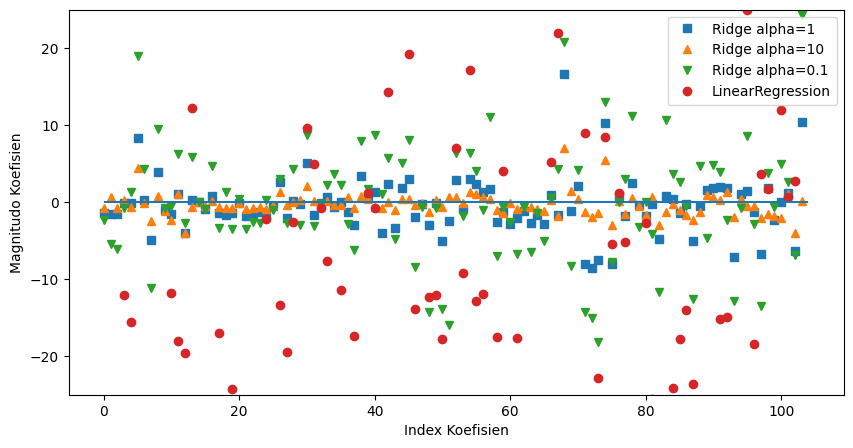

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(ridge.coef_, 's', label='Ridge alpha=1')
plt.plot(ridge10.coef_, '^', label='Ridge alpha=10')
plt.plot(ridge01.coef_, 'v', label='Ridge alpha=0.1')
plt.plot(lr.coef_, 'o', label='LinearRegression')
plt.xlabel('Index Koefisien')
plt.ylabel('Magnitudo Koefisien')
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()
plt.show()


## 11. Lasso Regression
Lasso memakai regularisasi L1 yang bisa membuat sebagian koefisien tepat nol.


In [99]:
lasso = Lasso().fit(X_train, y_train)
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
lasso0001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print('alpha=1      | Train:', round(lasso.score(X_train, y_train), 2), '| Test:', round(lasso.score(X_test, y_test), 2), '| Fitur aktif:', np.sum(lasso.coef_ != 0))
print('alpha=0.01   | Train:', round(lasso001.score(X_train, y_train), 2), '| Test:', round(lasso001.score(X_test, y_test), 2), '| Fitur aktif:', np.sum(lasso001.coef_ != 0))
print('alpha=0.0001 | Train:', round(lasso0001.score(X_train, y_train), 2), '| Test:', round(lasso0001.score(X_test, y_test), 2), '| Fitur aktif:', np.sum(lasso0001.coef_ != 0))


alpha=1      | Train: 0.29 | Test: 0.21 | Fitur aktif: 4
alpha=0.01   | Train: 0.9 | Test: 0.77 | Fitur aktif: 33
alpha=0.0001 | Train: 0.95 | Test: 0.64 | Fitur aktif: 96


## 12. Logistic Regression
Logistic Regression adalah model linear untuk classification.


In [100]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
logreg = LogisticRegression(max_iter=10000).fit(X_train, y_train)
logreg100 = LogisticRegression(C=100, max_iter=10000).fit(X_train, y_train)
logreg001 = LogisticRegression(C=0.01, max_iter=10000).fit(X_train, y_train)
print('C=1    | Train:', round(logreg.score(X_train, y_train), 3), '| Test:', round(logreg.score(X_test, y_test), 3))
print('C=100  | Train:', round(logreg100.score(X_train, y_train), 3), '| Test:', round(logreg100.score(X_test, y_test), 3))
print('C=0.01 | Train:', round(logreg001.score(X_train, y_train), 3), '| Test:', round(logreg001.score(X_test, y_test), 3))


C=1    | Train: 0.958 | Test: 0.958
C=100  | Train: 0.981 | Test: 0.965
C=0.01 | Train: 0.953 | Test: 0.951


## 13. Logistic Regression dengan L1
Saat penalty diganti menjadi L1, beberapa koefisien bisa menjadi nol.


C=0.001 | Train: 0.91 | Test: 0.92 | Fitur aktif: 3
C=1 | Train: 0.96 | Test: 0.96 | Fitur aktif: 10
C=100 | Train: 0.99 | Test: 0.98 | Fitur aktif: 23


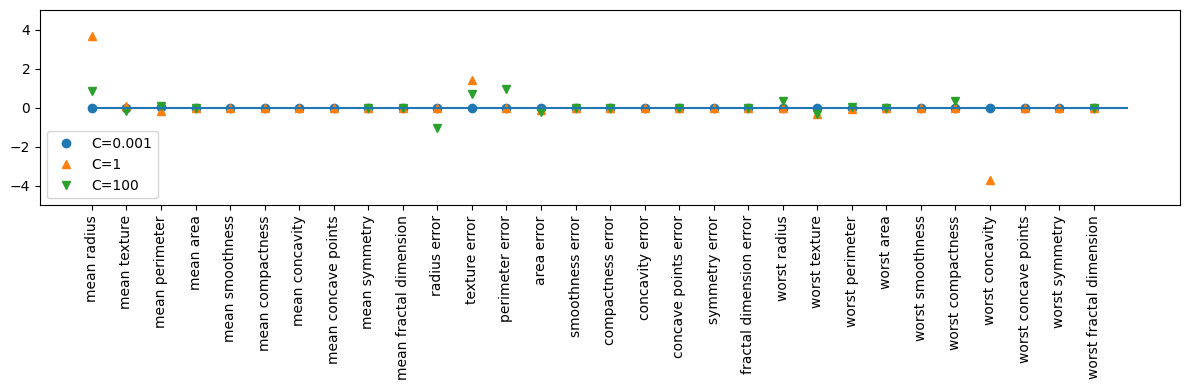

In [101]:
plt.figure(figsize=(12, 4))
for C, marker in zip([0.001, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=10000).fit(X_train, y_train)
    print(f'C={C} | Train: {lr_l1.score(X_train, y_train):.2f} | Test: {lr_l1.score(X_test, y_test):.2f} | Fitur aktif: {np.sum(lr_l1.coef_ != 0)}')
    plt.plot(lr_l1.coef_.T, marker, label=f'C={C}')
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.legend(loc=3)
plt.tight_layout()
plt.show()


## 14. LinearSVC multiclass
LinearSVC bisa dipakai untuk kasus multiclass dengan pendekatan one-vs-rest.


In [102]:
X_blobs, y_blobs = make_blobs(random_state=42)
linear_svm = LinearSVC(max_iter=10000).fit(X_blobs, y_blobs)
print('Shape coef_     :', linear_svm.coef_.shape)
print('Shape intercept_:', linear_svm.intercept_.shape)


Shape coef_     : (3, 2)
Shape intercept_: (3,)


## 15. GaussianNB dan BernoulliNB
Naive Bayes adalah baseline yang cepat untuk classification.


In [103]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
gnb = GaussianNB().fit(X_train, y_train)
print('GaussianNB train:', round(gnb.score(X_train, y_train), 2))
print('GaussianNB test :', round(gnb.score(X_test, y_test), 2))
X_bin = np.array([[0, 1, 0, 1], [1, 0, 1, 1], [0, 0, 0, 1], [1, 0, 1, 0]])
y_bin = np.array([0, 1, 0, 1])
bnb = BernoulliNB().fit(X_bin, y_bin)
print('BernoulliNB pred:', bnb.predict(X_bin))
print('BernoulliNB acc :', round(bnb.score(X_bin, y_bin), 2))


GaussianNB train: 0.95
GaussianNB test : 0.94
BernoulliNB pred: [0 1 0 1]
BernoulliNB acc : 1.0


## 16. Decision Tree
Decision tree mudah dipahami, tetapi mudah overfit kalau tidak dibatasi.


In [104]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
tree_depth4 = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train)
print('Tanpa pruning | Train:', round(tree.score(X_train, y_train), 3), '| Test:', round(tree.score(X_test, y_test), 3))
print('max_depth=4   | Train:', round(tree_depth4.score(X_train, y_train), 3), '| Test:', round(tree_depth4.score(X_test, y_test), 3))


Tanpa pruning | Train: 1.0 | Test: 0.937
max_depth=4   | Train: 0.988 | Test: 0.951


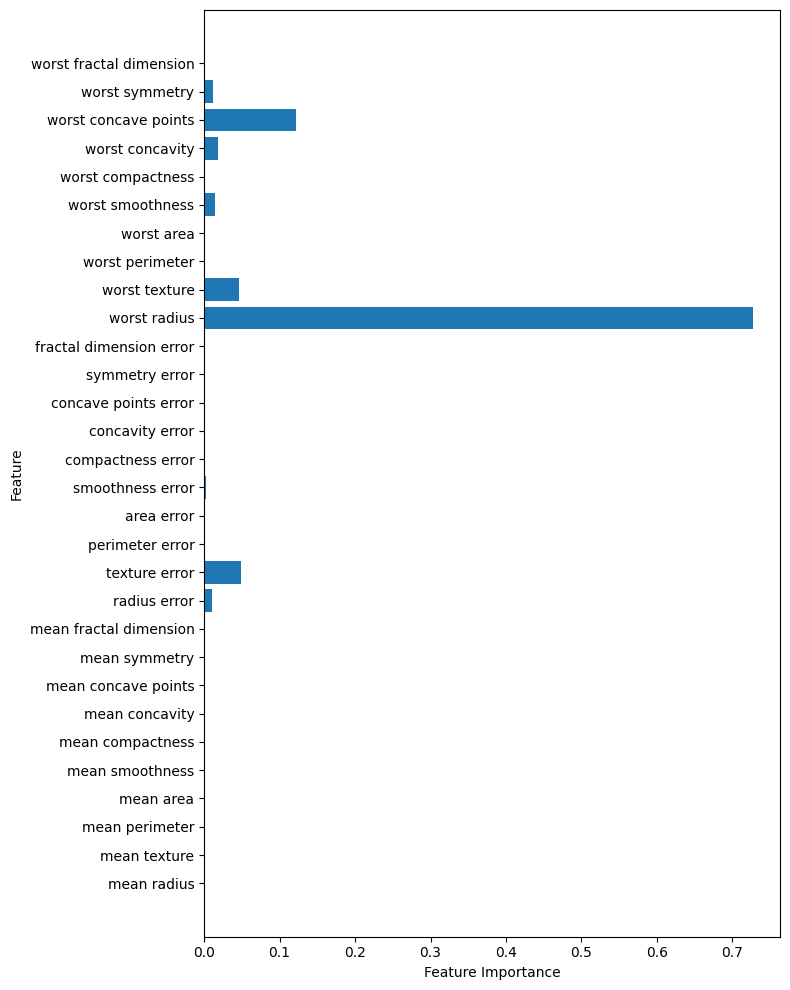

In [105]:
plt.figure(figsize=(8, 10))
plt.barh(range(cancer.data.shape[1]), tree_depth4.feature_importances_, align='center')
plt.yticks(np.arange(cancer.data.shape[1]), cancer.feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 17. Random Forest
Random Forest menggabungkan banyak decision tree sehingga hasilnya biasanya lebih stabil dan kuat dibanding satu tree tunggal.


In [106]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train, y_train)
print('Random Forest train:', round(forest.score(X_train, y_train), 3))
print('Random Forest test :', round(forest.score(X_test, y_test), 3))


Random Forest train: 1.0
Random Forest test : 0.972


## 18. Gradient Boosting
Gradient Boosting membangun tree secara berurutan untuk memperbaiki kesalahan model sebelumnya.


In [107]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
gbrt = GradientBoostingClassifier(random_state=0).fit(X_train, y_train)
gbrt_depth1 = GradientBoostingClassifier(random_state=0, max_depth=1).fit(X_train, y_train)
gbrt_lr001 = GradientBoostingClassifier(random_state=0, learning_rate=0.01).fit(X_train, y_train)
print('Default            | Train:', round(gbrt.score(X_train, y_train), 3), '| Test:', round(gbrt.score(X_test, y_test), 3))
print('max_depth=1        | Train:', round(gbrt_depth1.score(X_train, y_train), 3), '| Test:', round(gbrt_depth1.score(X_test, y_test), 3))
print('learning_rate=0.01 | Train:', round(gbrt_lr001.score(X_train, y_train), 3), '| Test:', round(gbrt_lr001.score(X_test, y_test), 3))


Default            | Train: 1.0 | Test: 0.965
max_depth=1        | Train: 0.991 | Test: 0.972
learning_rate=0.01 | Train: 0.988 | Test: 0.958


## 19. Kernelized SVM
SVM berbasis kernel sensitif terhadap scaling.


In [108]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
svc = SVC().fit(X_train, y_train)
print('Tanpa scaling   | Train:', round(svc.score(X_train, y_train), 3), '| Test:', round(svc.score(X_test, y_test), 3))
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svc_scaled = SVC().fit(X_train_scaled, y_train)
svc_1000 = SVC(C=1000).fit(X_train_scaled, y_train)
print('Dengan scaling  | Train:', round(svc_scaled.score(X_train_scaled, y_train), 3), '| Test:', round(svc_scaled.score(X_test_scaled, y_test), 3))
print('Scaling + C1000 | Train:', round(svc_1000.score(X_train_scaled, y_train), 3), '| Test:', round(svc_1000.score(X_test_scaled, y_test), 3))


Tanpa scaling   | Train: 0.904 | Test: 0.937
Dengan scaling  | Train: 0.984 | Test: 0.972
Scaling + C1000 | Train: 1.0 | Test: 0.958


## 20. Neural Network (MLP)
MLP juga sensitif terhadap scaling.


In [109]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
mlp_raw = MLPClassifier(random_state=42, max_iter=1000).fit(X_train, y_train)
print('Tanpa scaling | Train:', round(mlp_raw.score(X_train, y_train), 3), '| Test:', round(mlp_raw.score(X_test, y_test), 3))
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp = MLPClassifier(max_iter=1000, random_state=0).fit(X_train_scaled, y_train)
mlp_alpha1 = MLPClassifier(max_iter=1000, alpha=1, random_state=0).fit(X_train_scaled, y_train)
print('Dengan scaling | Train:', round(mlp.score(X_train_scaled, y_train), 3), '| Test:', round(mlp.score(X_test_scaled, y_test), 3))
print('Scaling + a=1 | Train:', round(mlp_alpha1.score(X_train_scaled, y_train), 3), '| Test:', round(mlp_alpha1.score(X_test_scaled, y_test), 3))


Tanpa scaling | Train: 0.939 | Test: 0.916
Dengan scaling | Train: 1.0 | Test: 0.972
Scaling + a=1 | Train: 0.988 | Test: 0.972


## 21. Uncertainty estimates
Beberapa classifier bisa memberikan skor keyakinan melalui `decision_function` atau probabilitas melalui `predict_proba`.


In [110]:
X, y = make_circles(noise=0.25, factor=0.5, random_state=1)
y_named = np.array(['blue', 'red'])[y]
X_train, X_test, y_train_named, y_test_named, y_train, y_test = train_test_split(X, y_named, y, random_state=0)
gbrt_bin = GradientBoostingClassifier(random_state=0).fit(X_train, y_train_named)
print('decision_function:', np.round(gbrt_bin.decision_function(X_test)[:6], 3))
print('predict_proba:')
print(np.round(gbrt_bin.predict_proba(X_test[:6]), 3))


decision_function: [ 4.136 -1.702 -3.951 -3.626  4.29   3.662]
predict_proba:
[[0.016 0.984]
 [0.846 0.154]
 [0.981 0.019]
 [0.974 0.026]
 [0.014 0.986]
 [0.025 0.975]]


In [111]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)
gbrt_multi = GradientBoostingClassifier(learning_rate=0.01, random_state=0).fit(X_train, y_train)
print('decision_function shape:', gbrt_multi.decision_function(X_test).shape)
print('predict_proba sample:')
print(np.round(gbrt_multi.predict_proba(X_test[:5]), 3))


decision_function shape: (38, 3)
predict_proba sample:
[[0.102 0.788 0.109]
 [0.783 0.109 0.107]
 [0.098 0.11  0.792]
 [0.102 0.788 0.109]
 [0.104 0.667 0.229]]


## 22. Ringkasan performa model
Tabel ini merangkum beberapa model utama pada cancer dataset untuk perbandingan singkat test score.


In [112]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
scaler_std = StandardScaler()
X_train_scaled_std = scaler_std.fit_transform(X_train)
X_test_scaled_std = scaler_std.transform(X_test)
results = []
results.append(['Logistic Regression', LogisticRegression(max_iter=10000).fit(X_train_scaled_std, y_train).score(X_test_scaled_std, y_test)])
results.append(['SVM', SVC().fit(X_train_scaled_std, y_train).score(X_test_scaled_std, y_test)])
results.append(['MLP', MLPClassifier(max_iter=1000, random_state=0).fit(X_train_scaled_std, y_train).score(X_test_scaled_std, y_test)])
results.append(['Random Forest', RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train, y_train).score(X_test, y_test)])
results.append(['Gradient Boosting', GradientBoostingClassifier(random_state=0).fit(X_train, y_train).score(X_test, y_test)])
pd.DataFrame(results, columns=['Model', 'Test Score'])


,Model,Test Score
0,Logistic Regression,0.958042
1,SVM,0.965035
2,MLP,0.972028
3,Random Forest,0.972028
4,Gradient Boosting,0.965035
